# Numerically minimising Pauli-weight

One frequently cited goal when designing an encoding $\mathcal{E}$ is to minimise the average number of Pauli-operators in the terms of the qubit Hamiltonian.

This can be done in a _Hamiltonian independent_ way, by considering the fermionic creation and annihilation operators individually. With $P(x)$ being the Pauli-weight of $x$,

$$P_{HI}(\mathcal{E}) = \frac{\sum_{i}^{M}{P(a_i^{\dagger})+P(a_i)}}{M}$$

If we have a specific Hamiltonian in mind, say the electronic structure hamiltonian, we can be more specific by finding the Pauli weight the set of Hamiltonian terms $\{h\}$ which result from encoding terms of the fermionic Hamiltonian ($a_i^{\dagger}a_j$ and $a_i^{\dagger}a_j^{\dagger}a_k a_l$). 

Note that we don't need to consider the Hamiltonian coefficents $\{\alpha_{i,j}, \alpha_{i,j,k,l}\}$ associated to each of those operators, so this Pauli-weight is _system independent_.

$$P_{HD}(\mathcal{E}, H_F) = \frac{\sum_{\set{h}}P(h)}{|\set{h}|}$$

When considering a real system (such as a water molecule in STO-3G), many of the terms of the fermionic Hamiltonian will represent transitions which are not allowed. As a result, some terms of the general qubit Hamiltonian will not be needed. 

This isn't the end of the story however, because the specific set of qubit operator terms which have non-zero coefficients depends on the enumeration scheme $f$ used in the encoding $\mathcal{E}_{f}$. Accounting for this, we have the _system dependent_ Pauli-weight:

$$P_{SD}(\mathcal{E}_{f}, H_F) = \frac{\sum_{h\in H_Q}P(h)}{|H_Q|}$$


# Example optimisations

First we'll import data we need specific to the water molecule in $STO-3G$.

In [1]:
import pickle
from pytest import fixture
from ferrmion.encode import TernaryTree, KNTO
from pathlib import Path

def water_integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/water_1e.pkl"), 'rb') as file:
        ones = pickle.load(file)

    with open(folder.joinpath("./data/water_2e.pkl"), 'rb') as file:
        twos = pickle.load(file)
    return (ones, twos)

tree = TernaryTree(14)

# $P_{HI}$

In [2]:
from ferrmion import FermionQubitEncoding
import numpy as np
def hamiltonian_indpendent_weight(encoding: FermionQubitEncoding):
    _, symplectics = encoding._build_symplectic_matrix()
    x_block, z_block = np.hsplit(symplectics, 2)
    operator_weights = np.sum(np.bitwise_or(x_block, z_block),axis=1)
    return np.mean(operator_weights)

In [3]:
ham_indep = {"jw":None,"pe": None,"bk": None,"jkmn": None}
ham_indep["jw"]=hamiltonian_indpendent_weight(tree.JordanWigner())
ham_indep["pe"]=hamiltonian_indpendent_weight(tree.ParityEncoding())
ham_indep["bk"]=hamiltonian_indpendent_weight(tree.BravyiKitaev())
ham_indep["jkmn"]=hamiltonian_indpendent_weight(tree.JKMN())
ham_indep["knto"]=hamiltonian_indpendent_weight(KNTO(14))

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_96177/3356065180.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


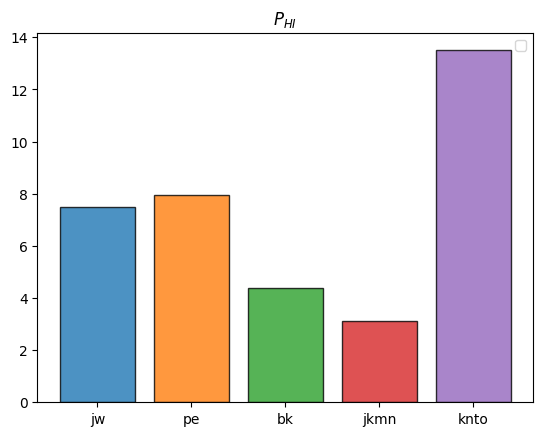

In [40]:
import matplotlib.pyplot as plt
bar_colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red', 'tab:purple']
bar_labels = [k for k in ham_indep.keys()]
fig, ax = plt.subplots()
ax.bar(ham_indep.keys(), ham_indep.values(), color=bar_colors, linewidth=1, edgecolor="black", alpha=0.8)
ax.legend()
ax.set_title("$P_{HI}$")
plt.show()

So it seems there is a clear benefit to the multi-branch Bravyi-kitaev and JKMN (minimum height) trees!

Let's move on to see how these encodings behave when applied to the electronic structure Hamiltonian.

# $P_{HD}$

In [41]:
KNTO(14)._build_symplectic_matrix()[0]

array([0, 1, 0, 1, 2, 3, 2, 3, 0, 1, 0, 1, 2, 3, 2, 3, 0, 1, 0, 1, 2, 3,
       2, 3, 0, 1, 0, 1], dtype=uint8)

In [42]:
from ferrmion.optimize.enumeration import lambda_plus_mu
from ferrmion.optimize.enumeration.cost_functions import pauli_weighted_norm
from ferrmion.hamiltonians import molecular_hamiltonian_template
from ferrmion.hamiltonians import fill_template
import functools
ones, twos = water_integrals()

templates = {"jw":None,"pe": None,"bk": None,"jkmn": None}

ipowers, symplectics = tree.JW()._build_symplectic_matrix()
templates["jw"] = molecular_hamiltonian_template(ipowers, symplectics)

ipowers, symplectics = tree.ParityEncoding()._build_symplectic_matrix()
templates["pe"] = molecular_hamiltonian_template(ipowers, symplectics)

ipowers, symplectics = tree.BK()._build_symplectic_matrix()
templates["bk"] = molecular_hamiltonian_template(ipowers, symplectics)

ipowers, symplectics = tree.JKMN()._build_symplectic_matrix()
templates["jkmn"] = molecular_hamiltonian_template(ipowers, symplectics)

ipowers, symplectics = KNTO(14)._build_symplectic_matrix()
templates["knto"] = molecular_hamiltonian_template(ipowers, symplectics)

In [43]:
import numpy as np
def template_pauli_weight(template):
    return np.mean([len(k) - k.count("I") for k in template.keys()])

ham_dep = {k: template_pauli_weight(v) for k,v in templates.items()}

/var/folders/b6/r25qxhld1ls1sll052q1dw5h0000gn/T/ipykernel_96177/1235852636.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


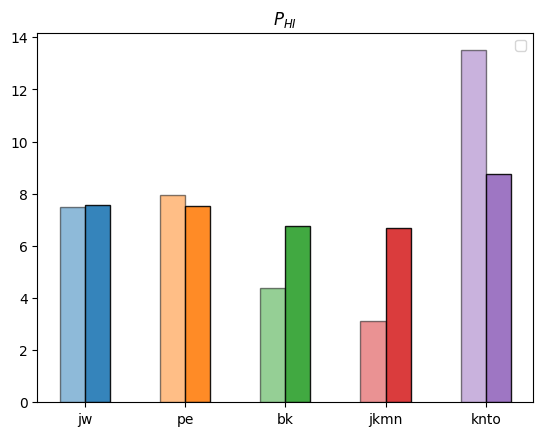

In [44]:
import matplotlib.pyplot as plt
bar_labels = [k for k in ham_dep.keys()]
width = 0.25
x = np.arange(len(ham_indep))
fig, ax = plt.subplots()
ax.bar(x-width/2, ham_indep.values(), width=width, color=bar_colors, linewidth=1, edgecolor="black", alpha=0.5)
ax.bar(x+width/2, ham_dep.values(), width=width,color=bar_colors, linewidth=1, edgecolor="black", alpha=0.9)
ax.set_xticks(x, ham_dep.keys())
ax.legend()
ax.set_title("$P_{HI}$")
plt.show()

How interesting! The Bravyi-Kitaev and JKMN encodings have lost their advantage now that we're considering the application of encodings to a Hamiltonian.

Conversely, the k-NTO encoding now performs much more similarly to the ternary trees. 

# $P_{SD}$

Let's start by finding $P_{SD}$ for a set of random permutations of the fermionic mode labels.

In [80]:
def fill_template_find_norm(template, ones, twos, permutation):
    ham = fill_template(template, 0, ones, 0.5*twos, {i:permutation[i] for i in range(len(permutation))})
    return pauli_weighted_norm(ham)

As a test, lets check the naive enumeration, $(0,1,...,M) \to (0,1,...,M)$

In [81]:
naive = {}
for encoding, template in templates.items():
    perm = [*range(14)]
    naive[encoding] = {}
    naive[encoding] = fill_template_find_norm(template, ones, twos, perm)[0]
naive

{'jw': np.float64(191.40252833977175),
 'pe': np.float64(256.99667953199605),
 'bk': np.float64(291.9131210131432),
 'jkmn': np.float64(277.6049767305088),
 'knto': np.float64(667.3119791169846)}

Now we can run a set of random permutations

Increasing the number of pemutations to try here will take longer but the plots later are more satisfying!

In [87]:
import numpy as np
rng = np.random.default_rng(1017)
distributions = {k: [] for k in templates.keys()}

for i in range(200):
    perm = rng.permutation(14)
    for encoding, template in templates.items():
        distributions[encoding].append(fill_template_find_norm(template, ones, twos, perm)[0])

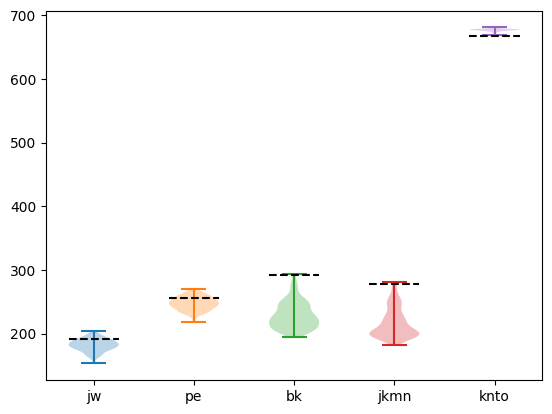

In [88]:
import matplotlib.pyplot as plt

#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots()
pos = 0
for dist in distributions.values():
    axs.violinplot(dist, [pos])
    pos+=1
for pos, encoding in enumerate(naive):
    axs.hlines(naive[encoding],  pos-0.25, pos+0.25,  linestyles="--", color="black")

axs.set_xticks([*range(len(distributions))], labels=distributions.keys())
plt.show()

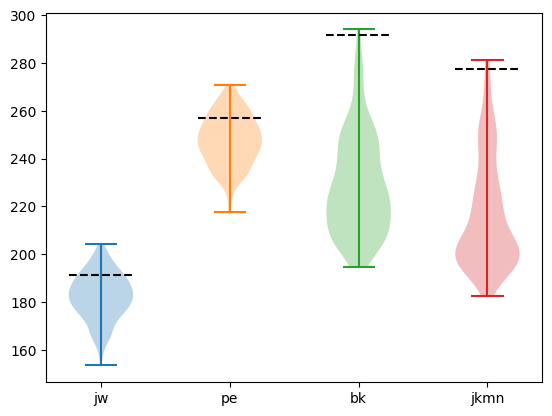

In [89]:
import matplotlib.pyplot as plt

#create histogram
n_bins = 30
alpha = 0.7

fig, axs = plt.subplots()
pos = 0
for dist in [v for k,v in distributions.items() if k != "knto"]:
    axs.violinplot(dist, [pos])
    pos+=1
for pos, encoding in enumerate(naive):
    if encoding == "knto":
        continue
    axs.hlines(naive[encoding],  pos-0.25, pos+0.25,  linestyles="--", color="black")

axs.set_xticks([*range(len(distributions)-1)], labels=[*distributions.keys()][:-1])
plt.show()

In [90]:
def run_evolutionary(template):
    evaluate = functools.partial(fill_template_find_norm, template, ones, twos)
    best, logbook = lambda_plus_mu(14, evaluate, 150, 5)
    return logbook[-1]["min"]

In [91]:
mins = {}
for encoding,  template in templates.items():
    mins[encoding] = run_evolutionary(template)

/Users/michaelwilliamsdelabastida/Code/ferrmion/.venv/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'FitnessMin' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "
/Users/michaelwilliamsdelabastida/Code/ferrmion/.venv/lib/python3.13/site-packages/deap/creator.py:185: RuntimeWarning: A class named 'Individual' has already been created and it will be overwritten. Consider deleting previous creation of that class or rename it.
  warnings.warn("A class named '{0}' has already been created and it "


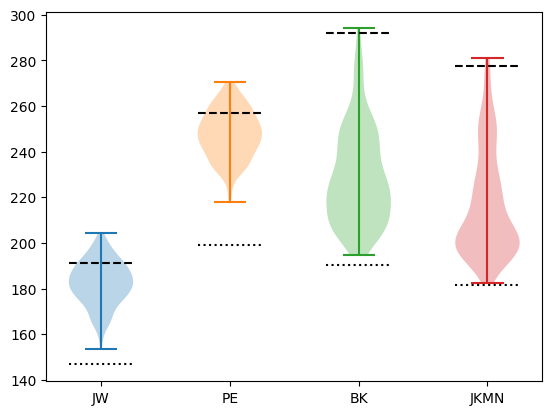

In [ ]:
fig, axs = plt.subplots()
pos = 0
for encoding, dist in distributions.items():
    if encoding == "knto":
        continue
    axs.violinplot(dist, [pos])
    pos+=1
axs.set_xticks([*range(len(distributions)-1)], labels=["JW", "PE", "BK", "JKMN"])
for pos, encoding in enumerate(naive):
    if encoding == "knto":
        continue
    axs.hlines(naive[encoding],  pos-0.25, pos+0.25,  linestyles="--", color="black")
    axs.hlines(mins[encoding],  pos-0.25, pos+0.25,  linestyles=":", color="black")
plt.show()